# Descubrimiento de EDP a partir de datos: PINNs inversos

### An&aacute;lisis num&eacute;rico de ecuaciones diferenciales &mdash; cuaderno de clase (parte inversa)

En el cuaderno anterior us&aacute;bamos un PINN para *resolver* una EDP conocida (problema **directo**). Aqu&iacute; damos la vuelta a la pregunta, como en la segunda mitad de Raissi, Perdikaris y Karniadakis (2019): la EDP tiene **coeficientes desconocidos** y solo disponemos de **datos ruidosos** de la soluci&oacute;n. Queremos *descubrir* esos coeficientes &mdash; el llamado problema **inverso** o de *data-driven discovery*.

El ejemplo estrella del art&iacute;culo es Navier&ndash;Stokes: a partir de medidas dispersas del campo de velocidad de un flujo alrededor de un cilindro (la calle de v&oacute;rtices de K&aacute;rm&aacute;n), el PINN identifica los par&aacute;metros $\lambda_1,\lambda_2$ y reconstruye el campo de presi&oacute;n que nunca observ&oacute; (ecs. 17&ndash;19 del art&iacute;culo). Como Navier&ndash;Stokes 2D requiere un conjunto de datos pesado, aqu&iacute; usamos su **an&aacute;logo 1D tratable**: la ecuaci&oacute;n de **Burgers**, un modelo no lineal de fluidos que combina convecci&oacute;n y difusi&oacute;n,

$$u_t + \lambda_1\, u\,u_x = \lambda_2\, u_{xx}.$$

Trataremos $\lambda_1$ (convecci&oacute;n) y $\lambda_2$ (viscosidad) como **desconocidos** y los recuperaremos a partir de observaciones ruidosas, con la misma maquinaria del art&iacute;culo.


**C&oacute;mo usarlo.** Ejecute las celdas de arriba hacia abajo. En Colab, `scipy` y `torch` ya est&aacute;n instalados. El entrenamiento es m&aacute;s pesado que en el cuaderno directo; para acelerarlo conviene activar la GPU: *Entorno de ejecuci&oacute;n &rarr; Cambiar tipo de entorno &rarr; GPU*.

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

import torch
import torch.nn as nn

np.random.seed(0)
torch.manual_seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch', torch.__version__, '| dispositivo:', device)


PyTorch 2.11.0+cpu | dispositivo: cpu


## 1. El problema inverso y su formulaci&oacute;n

Partimos de la ecuaci&oacute;n de Burgers viscosa en $x\in[-1,1]$, con condiciones peri&oacute;dicas y condici&oacute;n inicial $u(0,x)=-\sin(\pi x)$. Los valores **verdaderos** (que fingiremos no conocer) son $\lambda_1^\star=1$ y $\lambda_2^\star=0.1$.

La formulaci&oacute;n es la misma del cuaderno directo, con dos a&ntilde;adidos: los coeficientes pasan a ser **par&aacute;metros entrenables**, y aparece un t&eacute;rmino de **ajuste a los datos**. Definimos el residuo

$$r(t,x)\;=\;u_t+\lambda_1\,u\,u_x-\lambda_2\,u_{xx},$$

calculado por diferenciaci&oacute;n autom&aacute;tica, y minimizamos la suma de un error de datos y un error de f&iacute;sica (la $\mathrm{MSE}$ de la ec. 19 de Raissi):

$$\mathcal{L}(\theta,\lambda_1,\lambda_2)=\underbrace{\frac{1}{N_d}\sum_i\bigl|\tilde u(t_d^i,x_d^i)-u_d^i\bigr|^2}_{\text{datos}}\;+\;\underbrace{\frac{1}{N_f}\sum_j\bigl|r(t_f^j,x_f^j)\bigr|^2}_{\text{residuo (f\'isica)}}.$$

Al minimizar, la red aprende a la vez la soluci&oacute;n $\tilde u$ **y** los coeficientes $\lambda_1,\lambda_2$.


## 2. Generaci&oacute;n de los datos de referencia

Para tener "mediciones", primero resolvemos la ecuaci&oacute;n con un m&eacute;todo cl&aacute;sico (l&iacute;neas, con diferencias finitas peri&oacute;dicas e integraci&oacute;n temporal de `scipy`). En un caso real, estos datos vendr&iacute;an de un experimento.


campo generado: (101, 256) | max|u| = 1.0


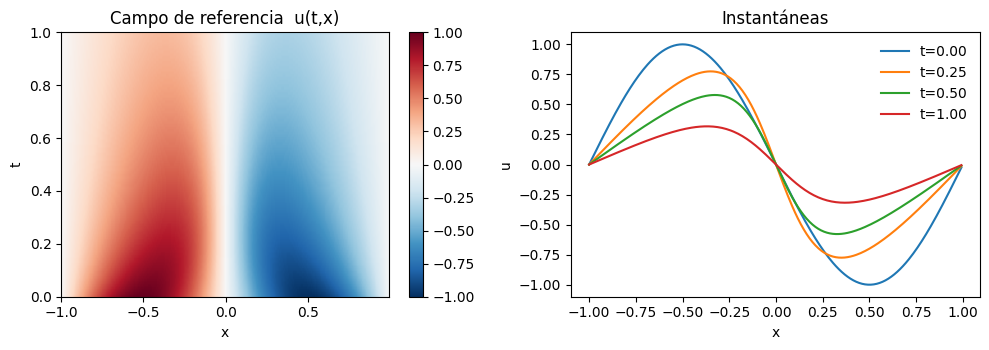

In [ ]:
lam1_true, lam2_true = 1.0, 0.1          # valores verdaderos (a recuperar)
Nx = 256
x_grid = np.linspace(-1, 1, Nx, endpoint=False)
dx = x_grid[1] - x_grid[0]

def burgers_rhs(t, u):
    up = np.roll(u, -1); um = np.roll(u, 1)
    ux  = (up - um) / (2*dx)
    uxx = (up - 2*u + um) / dx**2
    return -lam1_true * u * ux + lam2_true * uxx

u0 = -np.sin(np.pi * x_grid)
T = 1.0
t_grid = np.linspace(0, T, 101)
sol = solve_ivp(burgers_rhs, [0, T], u0, t_eval=t_grid,
                method='RK45', rtol=1e-7, atol=1e-9, max_step=0.005)
U = sol.y.T                                # campo de referencia, forma (nt, nx)
print('campo generado:', U.shape, '| max|u| =', round(float(np.abs(U).max()), 3))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.6))
im = a1.imshow(U, aspect='auto', origin='lower',
               extent=[x_grid.min(), x_grid.max(), 0, T], cmap='RdBu_r')
a1.set_xlabel('x'); a1.set_ylabel('t'); a1.set_title('Campo de referencia  u(t,x)')
fig.colorbar(im, ax=a1)
for k in [0, 25, 50, 100]:
    a2.plot(x_grid, U[k], label=f't={t_grid[k]:.2f}')
a2.set_xlabel('x'); a2.set_ylabel('u'); a2.set_title('Instantáneas'); a2.legend(frameon=False)
plt.tight_layout(); plt.show()


## 3. Observaciones dispersas y ruidosas

Imitando a Raissi (que entrena con apenas el 1% de los datos), tomamos un subconjunto **aleatorio y disperso** de puntos $(t,x,u)$ y les a&ntilde;adimos ruido gaussiano. Estas son las &uacute;nicas "mediciones" que ver&aacute; el PINN.


2000 observaciones ruidosas (ruido sigma=0.01)


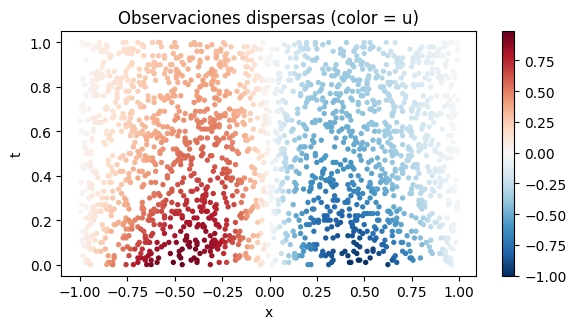

In [ ]:
N_obs   = 2000        # numero de observaciones dispersas
noise   = 0.01        # nivel de ruido (|u|<=1, asi que ~1%)

TT, XX = np.meshgrid(t_grid, x_grid, indexing='ij')
t_flat = TT.ravel(); x_flat = XX.ravel(); u_flat = U.ravel()
idx = np.random.choice(t_flat.size, N_obs, replace=False)
t_obs = t_flat[idx]; x_obs = x_flat[idx]
u_obs = u_flat[idx] + noise * np.random.randn(N_obs)
print(f'{N_obs} observaciones ruidosas (ruido sigma={noise})')

plt.figure(figsize=(6, 3.4))
plt.scatter(x_obs, t_obs, c=u_obs, s=8, cmap='RdBu_r')
plt.xlabel('x'); plt.ylabel('t'); plt.title('Observaciones dispersas (color = u)')
plt.colorbar(); plt.tight_layout(); plt.show()


## 4. El PINN inverso

La red toma $(t,x)$ y devuelve $\tilde u$. Las derivadas $u_t, u_x, u_{xx}$ del residuo se obtienen por diferenciaci&oacute;n autom&aacute;tica. Los coeficientes $\lambda_1,\lambda_2$ se declaran como par&aacute;metros entrenables (inicializados en $0$) y entran al optimizador junto con los pesos de la red.


In [ ]:
class MLP(nn.Module):
    def __init__(self, layers=(2, 40, 40, 40, 1)):
        super().__init__()
        mods = []
        for i in range(len(layers) - 1):
            mods.append(nn.Linear(layers[i], layers[i + 1]))
            if i < len(layers) - 2:
                mods.append(nn.Tanh())
        self.net = nn.Sequential(*mods)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)
    def forward(self, t, x):
        return self.net(torch.cat([t, x], dim=1))

def to_col(a):
    return torch.tensor(a, dtype=torch.float32, device=device).reshape(-1, 1)

# datos de observacion (sin gradiente)
t_d = to_col(t_obs); x_d = to_col(x_obs); u_d = to_col(u_obs)

# puntos de colocacion para el residuo (con gradiente)
N_f = 4000
tf = np.random.uniform(0, T, N_f); xf = np.random.uniform(-1, 1, N_f)
t_f = to_col(tf).requires_grad_(True); x_f = to_col(xf).requires_grad_(True)

net = MLP().to(device)
lam1 = nn.Parameter(torch.tensor(0.0, device=device))
lam2 = nn.Parameter(torch.tensor(0.0, device=device))
opt  = torch.optim.Adam(list(net.parameters()) + [lam1, lam2], lr=1e-3)

def residual(t, x):
    u   = net(t, x)
    u_t = torch.autograd.grad(u,   t, torch.ones_like(u),   create_graph=True)[0]
    u_x = torch.autograd.grad(u,   x, torch.ones_like(u),   create_graph=True)[0]
    u_xx= torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
    return u_t + lam1 * u * u_x - lam2 * u_xx

n_steps = 12000
hist = {'l1': [], 'l2': []}
t0 = time.perf_counter()
for it in range(n_steps + 1):
    opt.zero_grad()
    loss_data = ((net(t_d, x_d) - u_d)**2).mean()
    loss_phys = (residual(t_f, x_f)**2).mean()
    loss = loss_data + loss_phys
    loss.backward(); opt.step()
    hist['l1'].append(lam1.item()); hist['l2'].append(lam2.item())
    if it % 3000 == 0:
        print(f'  paso {it:5d}  L={loss.item():.3e}  '
              f'lam1={lam1.item():.4f}  lam2={lam2.item():.4f}')
train_time = time.perf_counter() - t0
print(f'\\nentrenamiento: {train_time:.1f} s')


  paso     0  L=2.570e-01  lam1=0.0010  lam2=-0.0010
  paso  3000  L=1.154e-03  lam1=0.6595  lam2=0.0993
  paso  6000  L=3.912e-04  lam1=0.8554  lam2=0.0986
  paso  9000  L=1.881e-04  lam1=0.9339  lam2=0.0994
  paso 12000  L=1.536e-04  lam1=0.9562  lam2=0.0997
\nentrenamiento: 430.4 s


## 5. Resultados: coeficientes recuperados

Comparamos los coeficientes inferidos con los verdaderos, vemos su trayectoria durante el entrenamiento y reconstruimos el campo completo (incluyendo zonas sin datos) para contrastarlo con la referencia.


coeficiente      verdadero    recuperado     error
----------------------------------------------------
lambda_1            1.0000        0.9562     4.38%
lambda_2            0.1000        0.0997     0.34%
error L2 relativo del campo reconstruido: 9.991e-03


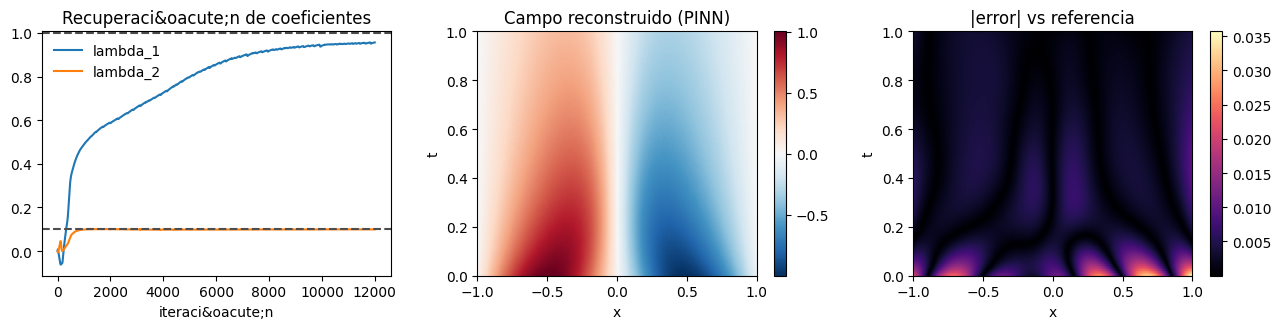

In [ ]:
err1 = 100 * abs(lam1.item() - lam1_true) / lam1_true
err2 = 100 * abs(lam2.item() - lam2_true) / lam2_true
print('='*52)
print(f'{"coeficiente":<14}{"verdadero":>12}{"recuperado":>14}{"error":>10}')
print('-'*52)
print(f'{"lambda_1":<14}{lam1_true:>12.4f}{lam1.item():>14.4f}{err1:>9.2f}%')
print(f'{"lambda_2":<14}{lam2_true:>12.4f}{lam2.item():>14.4f}{err2:>9.2f}%')
print('='*52)

# campo reconstruido por el PINN sobre toda la malla
with torch.no_grad():
    u_rec = net(to_col(TT.ravel()), to_col(XX.ravel())).cpu().numpy().reshape(U.shape)
relL2_field = np.sqrt(np.mean((u_rec - U)**2)) / np.sqrt(np.mean(U**2))
print(f'error L2 relativo del campo reconstruido: {relL2_field:.3e}')

fig, axs = plt.subplots(1, 3, figsize=(13, 3.4))
axs[0].plot(hist['l1'], label='lambda_1'); axs[0].plot(hist['l2'], label='lambda_2')
axs[0].axhline(lam1_true, color='0.3', ls='--'); axs[0].axhline(lam2_true, color='0.3', ls='--')
axs[0].set_xlabel('iteraci&oacute;n'); axs[0].set_title('Recuperaci&oacute;n de coeficientes'); axs[0].legend(frameon=False)
im1 = axs[1].imshow(u_rec, aspect='auto', origin='lower',
                    extent=[-1, 1, 0, T], cmap='RdBu_r'); axs[1].set_title('Campo reconstruido (PINN)')
axs[1].set_xlabel('x'); axs[1].set_ylabel('t'); fig.colorbar(im1, ax=axs[1])
im2 = axs[2].imshow(np.abs(u_rec - U), aspect='auto', origin='lower',
                    extent=[-1, 1, 0, T], cmap='magma'); axs[2].set_title('|error| vs referencia')
axs[2].set_xlabel('x'); axs[2].set_ylabel('t'); fig.colorbar(im2, ax=axs[2])
plt.tight_layout(); plt.show()


Pruebe a variar el nivel de ruido (`noise`) o el n&uacute;mero de observaciones (`N_obs`) y observe c&oacute;mo cambia la calidad de la recuperaci&oacute;n. Raissi reporta que, incluso con un 1% de ruido, los coeficientes se identifican con errores de pocos puntos porcentuales: la f&iacute;sica embebida en el residuo regulariza el ajuste y lo vuelve robusto.

## 6. Una nota sobre la formulaci&oacute;n en tiempo discreto

Hasta aqu&iacute; usamos un modelo en **tiempo continuo**: muestreamos puntos $(t,x)$ por todo el dominio espacio-temporal. Raissi propone tambi&eacute;n un modelo en **tiempo discreto** que conviene conocer (ecs. 20&ndash;25 del art&iacute;culo). La idea es aplicar un esquema de **Runge&ndash;Kutta impl&iacute;cito de $q$ etapas** entre dos instantes $t^n$ y $t^{n+1}$, y representar con la red las $q$ etapas intermedias:

$$u^{n+c_i}=u^n-\Delta t\sum_{j=1}^{q}a_{ij}\,\mathcal{N}[u^{n+c_j}],\qquad u^{n+1}=u^n-\Delta t\sum_{j=1}^{q}b_j\,\mathcal{N}[u^{n+c_j}].$$

Su gran virtud es que admite un n&uacute;mero de etapas $q$ muy grande sin costo prohibitivo (los par&aacute;metros crecen solo en la &uacute;ltima capa), lo que permite dar **pasos temporales enormes** y aprender la din&aacute;mica a partir de **apenas dos instant&aacute;neas** muy separadas en el tiempo &mdash; algo imposible para un integrador cl&aacute;sico. Es el camino indicado cuando los datos no cubren densamente el tiempo, sino que llegan en momentos aislados. No lo implementamos aqu&iacute;, pero es el complemento natural de este cuaderno.


## 7. Conclusiones y conexi&oacute;n con el curso

Este cuaderno muestra la cara que distingue a los PINN de los m&eacute;todos cl&aacute;sicos: con la **misma** funci&oacute;n de p&eacute;rdida &mdash; datos m&aacute;s residuo &mdash; y simplemente declarando los coeficientes como par&aacute;metros entrenables, resolvemos un problema **inverso** que un solver tradicional no aborda de forma natural. La f&iacute;sica embebida act&uacute;a como regularizador, lo que permite identificar par&aacute;metros a partir de datos escasos y ruidosos.

**Hilo con el curso y la tesis.** Esta es exactamente la maquinaria del ejemplo de Navier&ndash;Stokes, y el puente con la unidad de EDE: dada la ecuaci&oacute;n de Fokker&ndash;Planck (la cara distribucional de una difusi&oacute;n de It&ocirc;) y observaciones de "part&iacute;culas" &mdash; trayectorias muestreadas &mdash;, un PINN inverso permite **inferir los coeficientes de deriva y difusi&oacute;n**, el an&aacute;logo de estimar par&aacute;metros de mutaci&oacute;n o selecci&oacute;n a partir de datos de frecuencias al&eacute;licas.

**Dos advertencias.** Los problemas inversos pueden ser **mal planteados**: distintos coeficientes pueden explicar casi igual de bien los datos (no unicidad), por lo que conviene incorporar conocimiento previo o m&aacute;s observaciones. Y, como siempre, una p&eacute;rdida peque&ntilde;a no garantiza una recuperaci&oacute;n correcta: hay que validar contra datos independientes o contrastar con una soluci&oacute;n de referencia.
